In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from tqdm import tqdm

from pulse_analysis import read_root_file, format_root_data
from pulse_analysis import find_hits

# Load the data

In [2]:
max_events = 10000

filename = '/disk/gfs_atp/lhoetz/marmotx/XDetector_DC_OR_800V/XDetector_DC_OR_800V_Module_0_0.root'
_ar = read_root_file(filename, max_events=max_events)
data = format_root_data(_ar, n_baseline_samples=50)

n = data['wfs_raw'].shape[0]
n_samples = data['wfs_raw'].shape[-1]

Raw file keys: ['t1;8', 't1;7']
Number of events: 10000
Sample length: 200


# Perform simple pulse finder

In [3]:
n_sigma_hitfinder_threshold = 4
hits = find_hits(data, n_sigma_hitfinder_threshold=n_sigma_hitfinder_threshold)

100%|██████████| 10000/10000 [00:01<00:00, 6668.17it/s]


# Plot raw pulse areas

/disk/groups/atp/miniconda3/envs/mmx/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


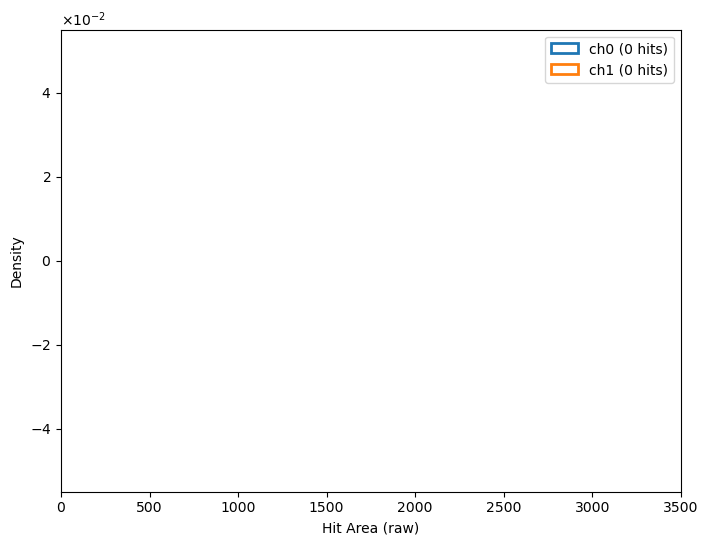

In [4]:
ch0_areas_raw = hits['hit_area_raw'][hits['channel']==0]
ch1_areas_raw = hits['hit_area_raw'][hits['channel']==1]
bins = np.linspace(0, 3500, 101)

plt.figure(figsize=(8, 6))
hist_ch0_raw = plt.hist(ch0_areas_raw, bins=bins, histtype='step', linewidth=2, density=True, label='ch0 ({} hits)'.format(len(ch0_areas_raw)))
hist_ch1_raw = plt.hist(ch1_areas_raw, bins=bins, histtype='step', linewidth=2, density=True, label='ch1 ({} hits)'.format(len(ch1_areas_raw)))
plt.xlabel('Hit Area (raw)')
plt.ylabel('Density')
plt.legend()

plt.xlim(0, 3500)
plt.gca().yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.show()

In [5]:
def gauss(x, mu, sig, A):
    return A * np.exp(-((x - mu) ** 2) / sig**2)

bin_edges = hist_ch0_raw[1]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fit_min = 800
fit_mask = bin_centers > fit_min

popt_ch0, _ = curve_fit(
    gauss,
    bin_centers[fit_mask],
    hist_ch0_raw[0][fit_mask],
    p0=[1400, 200, 1e-4],
)
popt_ch1, _ = curve_fit(
    gauss,
    bin_centers[fit_mask],
    hist_ch1_raw[0][fit_mask],
    p0=[1400, 200, 1e-4],
)

mu0, sig0, A0 = popt_ch0
mu1, sig1, A1 = popt_ch1

fig, ax = plt.subplots(figsize=(8, 6))

ax.step(bin_centers, hist_ch0_raw[0], where="mid", color="tab:blue", lw=2)
ax.plot(
    bin_centers,
    gauss(bin_centers, *popt_ch0),
    color="royalblue",
    lw=3,
    label=fr"ch0 fit: $\mu={mu0:.1f}$",
)

ax.step(bin_centers, hist_ch1_raw[0], where="mid", color="tab:orange", lw=2)
ax.plot(
    bin_centers,
    gauss(bin_centers, *popt_ch1),
    color="darkorange",
    lw=3,
    label=fr"ch1 fit: $\mu={mu1:.1f}$",
)

ax.axvline(fit_min, ls="--", color="0.4", lw=1, label="fit range start")

ax.set_xlabel("Hit Area (raw)")
ax.set_ylabel("Density")
ax.legend()

ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

ax.grid(alpha=0.2)
plt.show()

ValueError: array must not contain infs or NaNs

In [ ]:
adc_to_pe = [1/ popt_ch0[0], 1/popt_ch1[0]]
print("ADC to PE conversion factors:")
print("Channel 0 -> PE conversion factor: {:.6f} PE/ADC".format(adc_to_pe[0]))
print("Channel 1 -> PE conversion factor: {:.6f} PE/ADC".format(adc_to_pe[1]))

ADC to PE conversion factors:
Channel 0 -> PE conversion factor: 0.000770 PE/ADC
Channel 1 -> PE conversion factor: 0.000769 PE/ADC


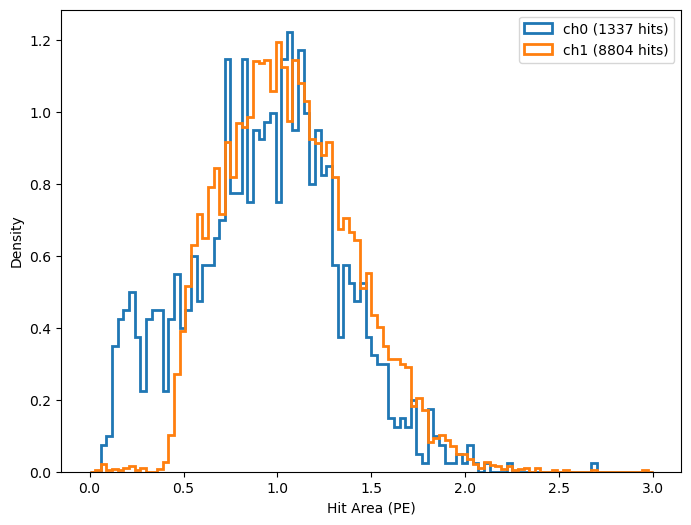

In [ ]:
ch0_areas_pe = hits['hit_area_raw'][hits['channel']==0] * adc_to_pe[0]
ch1_areas_pe = hits['hit_area_raw'][hits['channel']==1] * adc_to_pe[1]
bins = np.linspace(0, 3, 101)

plt.figure(figsize=(8, 6))
hist_ch0 = plt.hist(ch0_areas_pe, bins=bins, histtype='step', linewidth=2, density=True, label='ch0 ({} hits)'.format(len(ch0_areas_pe)))
hist_ch1 = plt.hist(ch1_areas_pe, bins=bins, histtype='step', linewidth=2, density=True, label='ch1 ({} hits)'.format(len(ch1_areas_pe)))

plt.ylabel('Density')
plt.xlabel('Hit Area (PE)')

plt.legend()
plt.show()